In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns

In [2]:
!curl -L -o data.csv https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  5  853k    5 50614    0     0  61013      0  0:00:14 --:--:--  0:00:14 61054
100  853k  100  853k    0     0   527k      0  0:00:01  0:00:01 --:--:--  527k


In [3]:
car_df = pd.read_csv('data.csv')
car_df

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369
...,...,...,...,...,...,...,...,...,...,...,...
9699,140,5.0,164.0,2981.107371,17.3,2013,Europe,Diesel,Front-wheel drive,NaN,15.101802
9700,180,NaN,154.0,2439.525729,15.0,2004,USA,Gasoline,All-wheel drive,0.0,17.962326
9701,220,2.0,138.0,2583.471318,15.1,2008,USA,Diesel,All-wheel drive,-1.0,17.186587
9702,230,4.0,177.0,2905.527390,19.4,2011,USA,Diesel,Front-wheel drive,1.0,15.331551


In [4]:
df = car_df[['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']]
df

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.433759,2003,13.231729
1,130,97.0,3149.664934,2007,13.688217
2,170,78.0,3079.038997,2018,14.246341
3,220,NaN,2542.392402,2009,16.912736
4,210,140.0,3460.870990,2009,12.488369
...,...,...,...,...,...
9699,140,164.0,2981.107371,2013,15.101802
9700,180,154.0,2439.525729,2004,17.962326
9701,220,138.0,2583.471318,2008,17.186587
9702,230,177.0,2905.527390,2011,15.331551


**1. EDA**

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

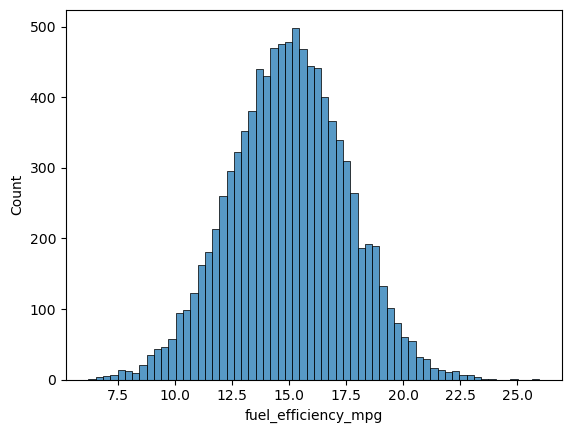

In [5]:
sns.histplot(df.fuel_efficiency_mpg)

In [6]:
df.isnull().sum()

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9704 entries, 0 to 9703
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  9704 non-null   int64  
 1   horsepower           8996 non-null   float64
 2   vehicle_weight       9704 non-null   float64
 3   model_year           9704 non-null   int64  
 4   fuel_efficiency_mpg  9704 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 379.2 KB


In [8]:
df.horsepower.median()

149.0

In [9]:
n=df.shape[0]
n_test = int(0.2 *n)
n_val = int(0.2 * n)
n_train = n-n_test-n_val
n_train,n_val,n_test

(5824, 1940, 1940)

In [10]:
# Train_Test_Split
# Create an array of indices from 0 to n-1
idx = np.arange(n)
# Set random seed for reproducibility
np.random.seed(42)
# Shuffle the indices randomly
np.random.shuffle(idx)
# Split the dataframe into training set using the first n_train indices
df_train = df.iloc[idx[:n_train]]
# Split the dataframe into validation set using the next n_val indices
df_val = df.iloc[idx[n_train:n_train+n_val]]
# Split the dataframe into test set using the remaining indices
df_test = df.iloc[idx[n_train+n_val:]]
# Reset the index of the training dataframe
df_train = df_train.reset_index(drop=True)
# Reset the index of the validation dataframe
df_val = df_val.reset_index(drop = True)
# Reset the index of the test dataframe
df_test = df_test.reset_index(drop=True)

In [11]:
y_train = df_train.fuel_efficiency_mpg
y_val = df_val.fuel_efficiency_mpg
y_test = df_test.fuel_efficiency_mpg

del df_train["fuel_efficiency_mpg"]
del df_val["fuel_efficiency_mpg"]
del df_test["fuel_efficiency_mpg"]

In [12]:
def train_linear_regression(X,y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones,X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    w0 = w_full[0]
    w = w_full[1:]
    return w0,w

In [67]:
def prepare_X_0(df_prep):
    df_prep = df_prep.copy()
    df_prep1 = df_prep.fillna(0)
    X1 = df_prep1.values
    return X1

In [14]:
X_train = prepare_X_0(df_train)[0]
w0,w = train_linear_regression(X_train,y_train)
X_val = prepare_X_0(df_val)[0]
y_pred_0 = w0 + X_val.dot(w)
y_pred_0

array([16.0373382 , 14.92522236, 11.86445895, ..., 13.69560868,
       13.62575126, 16.44936805])

In [15]:
X_train = prepare_X_0(df_train)[1]
w0,w = train_linear_regression(X_train,y_train)
X_val = prepare_X_0(df_val)[1]
y_pred_mean = w0 + X_val.dot(w)
y_pred_mean

array([15.73837497, 14.80338305, 12.03624928, ..., 14.01482574,
       13.72161355, 16.1936294 ])

In [16]:
def rmse(y,y_pred):
    se = (y-y_pred)**2
    mse = se.mean()
    return np.sqrt(mse)
    

In [17]:
rmse_0 = rmse(y_val,y_pred_0)
rmse_mean = rmse(y_val,y_pred_mean)

In [18]:
round(rmse_0,2),round(rmse_mean,2)

(np.float64(0.52), np.float64(0.46))

In [19]:
def train_linear_regression_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones,X])
    XTX = X.T.dot(X)
    XTX = XTX + r*np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0],w_full[1:]

In [20]:
X_train = prepare_X_0(df_train)[1]
rmses = {}
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0,w = train_linear_regression_reg(X_train,y_train,r)
    y_pred = w0 + X_val.dot(w)
    rmse_value = rmse(y_val,y_pred)
    rmses[r] = round(rmse_value,2)

print(rmses)
    
    

{0: np.float64(0.46), 0.01: np.float64(0.46), 0.1: np.float64(0.47), 1: np.float64(0.47), 5: np.float64(0.47), 10: np.float64(0.47), 100: np.float64(0.47)}


In [23]:
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
results = {}
for s in seeds:
    np.random.seed(42)
    np.random.shuffle(idx)
    # Split the dataframe into training set using the first n_train indices
    df_train = df.iloc[idx[:n_train]]
    # Split the dataframe into validation set using the next n_val indices
    df_val = df.iloc[idx[n_train:n_train+n_val]]
    # Split the dataframe into test set using the remaining indices
    df_test = df.iloc[idx[n_train+n_val:]]
    # Reset the index of the training dataframe
    df_train = df_train.reset_index(drop=True)
    # Reset the index of the validation dataframe
    df_val = df_val.reset_index(drop = True)
    # Reset the index of the test dataframe
    df_test = df_test.reset_index(drop=True)
    y_train = df_train.fuel_efficiency_mpg
    y_val = df_val.fuel_efficiency_mpg
    y_test = df_test.fuel_efficiency_mpg
    
    del df_train["fuel_efficiency_mpg"]
    del df_val["fuel_efficiency_mpg"]
    del df_test["fuel_efficiency_mpg"]
    X_train = prepare_X_0(df_train)[0]
    
    w0,w = train_linear_regression(X_train,y_train)
    X_val = prepare_X_0(df_val)[0]
    y_pred_0 = w0 + X_val.dot(w)

    rmse_s = rmse(y_val,y_pred_0)
    results[s] = rmse_s
    

In [30]:
arr = np.array(list(results.values()))
standard_dev = np.std(arr)
standard_dev

np.float64(0.006984401239266214)

In [77]:
# Train_Test_Split
# Create an array of indices from 0 to n-1
idx = np.arange(n)
# Set random seed for reproducibility
np.random.seed(9)
# Shuffle the indices randomly
np.random.shuffle(idx)
# Split the dataframe into training set using the first n_train indices
df_train = df.iloc[idx[:n_train]]
# Split the dataframe into validation set using the next n_val indices
df_val = df.iloc[idx[n_train:n_train+n_val]]
# Split the dataframe into test set using the remaining indices
df_test = df.iloc[idx[n_train+n_val:]]
# Reset the index of the training dataframe
df_train = df_train.reset_index(drop=True)
# Reset the index of the validation dataframe
df_val = df_val.reset_index(drop = True)
# Reset the index of the test dataframe
df_test = df_test.reset_index(drop=True)
y_train = df_train.fuel_efficiency_mpg
y_val = df_val.fuel_efficiency_mpg
y_test = df_test.fuel_efficiency_mpg

del df_train["fuel_efficiency_mpg"]
del df_val["fuel_efficiency_mpg"]
del df_test["fuel_efficiency_mpg"]

In [78]:
df_train
df_test

,engine_displacement,horsepower,vehicle_weight,model_year
0,240,NaN,3629.912976,2003
1,230,183.0,2675.510371,2011
2,270,176.0,3751.005987,2017
3,130,174.0,2703.817442,2017
4,240,NaN,2765.931806,2017
...,...,...,...,...
1935,130,190.0,2929.265698,2018
1936,270,127.0,3489.985764,2017
1937,240,177.0,3348.840052,2010
1938,250,150.0,2985.704630,2022


In [79]:
df_full_train = pd.concat([df_train,df_val])
df_full_train = df_full_train.reset_index(drop=True)
df_full_train

,engine_displacement,horsepower,vehicle_weight,model_year
0,240,136.0,4050.512290,2006
1,190,141.0,3195.866942,2017
2,200,184.0,3006.164370,2017
3,200,NaN,2947.143980,2022
4,250,132.0,3114.371978,2001
...,...,...,...,...
7759,200,167.0,3470.715658,2003
7760,180,144.0,3605.310144,2016
7761,180,154.0,3346.965671,2018
7762,210,152.0,2500.175687,2020


In [80]:
X_full_train = prepare_X_0(df_full_train)
X_full_train

array([[ 240.        ,  136.        , 4050.51228957, 2006.        ],
       [ 190.        ,  141.        , 3195.86694158, 2017.        ],
       [ 200.        ,  184.        , 3006.16436968, 2017.        ],
       ...,
       [ 180.        ,  154.        , 3346.96567067, 2018.        ],
       [ 210.        ,  152.        , 2500.17568746, 2020.        ],
       [ 260.        ,  174.        , 2702.25730066, 2011.        ]])

In [81]:
y_full_train = np.concatenate([y_train,y_val])
y_full_train

array([10.30469994, 13.47943378, 16.19065297, ..., 13.67814034,
       17.59323665, 16.06897494])

In [82]:
w0,w = train_linear_regression_reg(X_full_train,y_full_train,r=0.001)
X_test = prepare_X_0(df_test)[0]
y_pred = w0 + X_test.dot(w)
rmse(y_test,y_pred)

np.float64(4.375464065014558)

In [89]:
def prepare_X_0(df_prep):
    df_prep = df_prep.copy()
    df_prep = df_prep.fillna(0)
    return df_prep.values


In [93]:
idx = np.arange(n)
np.random.seed(9)
# Shuffle the indices randomly
np.random.shuffle(idx)
# Split the dataframe into training set using the first n_train indices
df_train = df.iloc[idx[:n_train]]
# Split the dataframe into validation set using the next n_val indices
df_val = df.iloc[idx[n_train:n_train+n_val]]
# Split the dataframe into test set using the remaining indices
df_test = df.iloc[idx[n_train+n_val:]]
# Reset the index of the training dataframe
df_train = df_train.reset_index(drop=True)
# Reset the index of the validation dataframe
df_val = df_val.reset_index(drop = True)
# Reset the index of the test dataframe
df_test = df_test.reset_index(drop=True)
y_train = df_train.fuel_efficiency_mpg.to_numpy()
y_val = df_val.fuel_efficiency_mpg.to_numpy()
y_test = df_test.fuel_efficiency_mpg.to_numpy()

del df_train["fuel_efficiency_mpg"]
del df_val["fuel_efficiency_mpg"]
del df_test["fuel_efficiency_mpg"]

In [94]:
df_full_train  = pd.concat([df_train, df_val], ignore_index=True)
y_full_train = np.concatenate([y_train,y_val])
y_full_train

array([10.30469994, 13.47943378, 16.19065297, ..., 13.67814034,
       17.59323665, 16.06897494])

In [95]:
X_full_train = prepare_X_0(df_full_train)
X_full_train

array([[ 240.        ,  136.        , 4050.51228957, 2006.        ],
       [ 190.        ,  141.        , 3195.86694158, 2017.        ],
       [ 200.        ,  184.        , 3006.16436968, 2017.        ],
       ...,
       [ 180.        ,  154.        , 3346.96567067, 2018.        ],
       [ 210.        ,  152.        , 2500.17568746, 2020.        ],
       [ 260.        ,  174.        , 2702.25730066, 2011.        ]])

In [96]:
X_test = prepare_X_0(df_test)
X_test

array([[ 240.        ,    0.        , 3629.91297555, 2003.        ],
       [ 230.        ,  183.        , 2675.51037108, 2011.        ],
       [ 270.        ,  176.        , 3751.00598701, 2017.        ],
       ...,
       [ 240.        ,  177.        , 3348.84005177, 2010.        ],
       [ 250.        ,  150.        , 2985.70463023, 2022.        ],
       [ 230.        ,  192.        , 3124.47364193, 2014.        ]])

In [97]:
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)
y_pred = w0 + X_test.dot(w)
y_pred

array([11.32557105, 16.7764655 , 11.36394577, ..., 13.37575113,
       15.11704257, 14.5599179 ])

In [99]:
rmse(y_test,y_pred)

np.float64(0.5156261299159695)